In [67]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETER SETUP
# ============================================================

def params_setup(vmax, L):

    des_speed_inv = 1.0 / vmax
    acc_exp = 4
    time_gap = 1.5
    comf_decel = 3.0
    min_gap = 2.0
    acc_max = 1.0
    del_t = 0.1
    length = 4.5

    params = [
        des_speed_inv,
        acc_exp,
        time_gap,
        comf_decel,
        min_gap,
        acc_max,
        del_t,
        length,
        L
    ]

    return params


def init_params():

    Nmax = 100
    L = 1000
    steps = 5000

    # Remove first 20 seconds of transient behaviour
    del_t = 0.1
    steps_measure = int(20/del_t)

    # 70 mph -> m/s
    vmax = 70 * 0.44704

    params = params_setup(vmax, L)

    return Nmax, L, steps, steps_measure, vmax, params


# ============================================================
# IDM UPDATE
# ============================================================

def upd_pos_vel(N, pos, vel, headway, dv, params):

    des_speed_inv, acc_exp, time_gap, comf_decel, \
    min_gap, acc_max, del_t, length, L = params

    v0 = 1.0 / des_speed_inv

    posnew = np.zeros(N)
    velnew = np.zeros(N)
    acc = np.zeros(N)

    for i in range(N):

        v = vel[i]
        s = max(headway[i], 1e-3)
        dv_i = dv[i]

        # Desired headway (correct IDM equation)
        s_star = min_gap + max(
            0,
            v*time_gap + (v*dv_i)/(2*np.sqrt(acc_max*comf_decel))
        )

        acc[i] = acc_max * (1 - (v/v0)**acc_exp - (s_star/s)**2)

    for i in range(N):

        v = vel[i]
        a = acc[i]

        # timestep rescaling if velocity becomes negative
        if v + a*del_t < 0:
            dt_star = -v/a
            velnew[i] = 0
            posnew[i] = pos[i] + v*dt_star
        else:
            velnew[i] = v + a*del_t
            posnew[i] = pos[i] + velnew[i]*del_t

        # periodic boundary conditions
        if posnew[i] >= L:
            posnew[i] -= L
        if posnew[i] < 0:
            posnew[i] += L

    return posnew, velnew


# ============================================================
# UPDATE HEADWAY
# ============================================================

def update_cars(N, pos, vel, params):

    length = params[7]
    L = params[8]

    headway = np.zeros(N)
    dv = np.zeros(N)

    for i in range(N):

        leader = (i + 1) % N

        if pos[leader] > pos[i]:
            s = pos[leader] - pos[i] - length
        else:
            s = L - pos[i] + pos[leader] - length

        headway[i] = s
        dv[i] = vel[i] - vel[leader]

    return headway, dv


# ============================================================
# DETECTOR (virtual speed camera)
# ============================================================

def detect_loop(N, pos, posnew, velnew, det_point):

    detections = []

    for i in range(N):

        crossed = (pos[i] < det_point and posnew[i] >= det_point)
        wrapped = (posnew[i] < pos[i] and
                   (pos[i] < det_point or posnew[i] >= det_point))

        if crossed or wrapped:
            detections.append(velnew[i])

    return detections


# ============================================================
# SIMULATION
# ============================================================

def Simulate_IDM(N, params, steps, steps_measure):

    L = params[8]
    del_t = params[6]

    pos = np.array([i*(params[7]+params[4]) for i in range(N)])
    vel = np.zeros(N)

    headway, dv = update_cars(N, pos, vel, params)

    track_flow = []
    track_dens = []
    track_local_vel = []

    det_point = L/2

    for step in range(steps):

        posnew, velnew = upd_pos_vel(N, pos, vel, headway, dv, params)

        if step >= steps_measure:

            dens = (N/L)*1000
            flow = dens * np.mean(velnew) * 3.6

            track_flow.append(flow)
            track_dens.append(dens)

            detections = detect_loop(N, pos, posnew, velnew, det_point)
            track_local_vel.extend(detections)

        pos = posnew
        vel = velnew
        headway, dv = update_cars(N, pos, vel, params)

    glob_flow = np.mean(track_flow)
    glob_dens = np.mean(track_dens)

    if len(track_local_vel) > 0:

        meas_time = (steps - steps_measure) * del_t

        loc_flow = (len(track_local_vel)/meas_time)*3600
        loc_avg_vel = np.mean(track_local_vel)*3.6
        loc_dens = loc_flow/loc_avg_vel if loc_avg_vel > 0 else 0

    else:
        loc_flow = loc_dens = loc_avg_vel = 0

    return glob_flow, glob_dens, loc_flow, loc_dens, loc_avg_vel


# ============================================================
# RUN DENSITY SWEEP
# ============================================================

Nmax, L, steps, steps_measure, vmax, params = init_params()

global_flow = []
global_dens = []
global_vel  = []

local_flow = []
local_dens = []
local_vel  = []

for N in range(2, Nmax+1, 2):

    g_flow, g_dens, l_flow, l_dens, l_vel = \
        Simulate_IDM(N, params, steps, steps_measure)

    global_flow.append(g_flow)
    global_dens.append(g_dens)
    global_vel.append(g_flow/g_dens if g_dens > 0 else 0)

    local_flow.append(l_flow)
    local_dens.append(l_dens)
    local_vel.append(l_vel)


# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(18,5))

# Flow–Density
plt.subplot(1,3,1)
plt.plot(global_dens, global_flow, 'o-', label='Global')
plt.plot(local_dens, local_flow, 's--', label='Local')
plt.xlabel('Density (cars/km)')
plt.ylabel('Flow (cars/hour)')
plt.title('Flow–Density')
plt.legend()
plt.grid(True)

# Velocity–Density
plt.subplot(1,3,2)
plt.plot(global_dens, global_vel, 'o-', label='Global')
plt.plot(local_dens, local_vel, 's--', label='Local')
plt.xlabel('Density (cars/km)')
plt.ylabel('Velocity (km/h)')
plt.title('Velocity–Density')
plt.legend()
plt.grid(True)

# Flow–Velocity
plt.subplot(1,3,3)
plt.plot(global_flow, global_vel, 'o-', label='Global')
plt.plot(local_flow, local_vel, 's--', label='Local')
plt.xlabel('Flow (cars/hour)')
plt.ylabel('Velocity (km/h)')
plt.title('Flow–Velocity')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ============================================================
# 1) PARAMETERS
# ============================================================

def params_setup(splim, L):
    """
    params = [des_speed_inv, acc_exp, time_gap, comf_decel, min_gap,
              acc_max, del_t, length, L]
    """
    des_speed_inv = 1.0 / splim
    del_t         = 0.4
    acc_exp       = 4
    time_gap      = 1.2
    min_gap       = 2.0
    comf_decel    = 1.5
    acc_max       = 1.2
    length        = 4.5  # car length (m)
    return [des_speed_inv, acc_exp, time_gap, comf_decel, min_gap, acc_max, del_t, length, L]


# ============================================================
# 2) IDM CORE
# ============================================================

def upd_pos_vel(Ncar, pos, vel, acc, headway, dv, posnew, velnew, params):
    des_speed_inv = params[0]
    acc_exp       = params[1]
    time_gap      = params[2]
    comf_decel    = params[3]
    min_gap       = params[4]
    acc_max       = params[5]
    del_t         = params[6]

    headway_safe = np.maximum(headway, 1e-3)
    des_headway = np.zeros(Ncar)

    for i in range(Ncar):
        des_headway[i] = min_gap + max(
            0.0,
            vel[i] * time_gap + (vel[i] * dv[i]) / (2.0 * np.sqrt(acc_max * comf_decel))
        )
        acc[i] = acc_max * (
            1.0
            - (vel[i] * des_speed_inv) ** acc_exp
            - (des_headway[i] / headway_safe[i]) ** 2
        )

    for i in range(Ncar):
        v_trial = vel[i] + acc[i] * del_t
        if v_trial >= 0:
            posnew[i] = pos[i] + vel[i] * del_t + 0.5 * acc[i] * del_t**2
            velnew[i] = v_trial
        else:
            # car stops before end of step
            if acc[i] < 0:
                del_t_star = -vel[i] / acc[i]
            else:
                del_t_star = del_t
            posnew[i] = pos[i] + vel[i] * del_t_star + 0.5 * acc[i] * del_t_star**2
            velnew[i] = 0.0

    return posnew, velnew, acc


# ============================================================
# 3) RING (CIRCULAR) LANE UPDATE
# ============================================================

def rebuild_ring_headway_dv(pos, vel, params):
    L      = params[8]
    length = params[7]
    N      = len(pos)
    headway = np.zeros(N)
    dv      = np.zeros(N)

    # array order defines leader: i-1 is leader of i
    for i in range(N):
        headway[i] = pos[i-1] - pos[i] - length
        if headway[i] < 0:
            headway[i] += L
        dv[i] = vel[i] - vel[i-1]

    headway = np.maximum(headway, 1e-3)
    return headway, dv

def step_ring(pos, vel, params):
    N = len(pos)
    if N == 0:
        return pos, vel

    headway, dv = rebuild_ring_headway_dv(pos, vel, params)

    acc    = np.zeros(N)
    posnew = np.zeros(N)
    velnew = np.zeros(N)

    posnew, velnew, acc = upd_pos_vel(N, pos, vel, acc, headway, dv, posnew, velnew, params)

    L = params[8]
    pos = np.mod(posnew, L)
    vel = np.maximum(velnew, 0.0)

    # keep a stable ordering convention: descending positions
    order = np.argsort(pos)[::-1]
    return pos[order], vel[order]


# ============================================================
# 4) SLIP LANE UPDATE (IDM)
# ============================================================

def rebuild_open_headway_dv(pos, vel, params, leader_pos, leader_vel):
    """
    Open lane: cars are ordered front->back (largest pos first).
    leader_pos/leader_vel define the virtual "leader" ahead of the front car.
    """
    length = params[7]
    N = len(pos)
    headway = np.zeros(N)
    dv      = np.zeros(N)

    for i in range(N):
        if i == 0:
            headway[i] = leader_pos - pos[i] - length
            dv[i]      = vel[i] - leader_vel
        else:
            headway[i] = pos[i-1] - pos[i] - length
            dv[i]      = vel[i] - vel[i-1]

    headway = np.maximum(headway, 1e-3)
    return headway, dv

def step_open_lane(pos, vel, params, lane_len, leader_vel=0.0):
    """
    IDM step on a finite open lane [0, lane_len].
    The "leader" is at leader_pos = lane_len (end of lane).
    If cars can't progress, they will queue.
    """
    N = len(pos)
    if N == 0:
        return pos, vel

    leader_pos = lane_len
    headway, dv = rebuild_open_headway_dv(pos, vel, params, leader_pos, leader_vel)

    acc    = np.zeros(N)
    posnew = np.zeros(N)
    velnew = np.zeros(N)

    posnew, velnew, acc = upd_pos_vel(N, pos, vel, acc, headway, dv, posnew, velnew, params)

    # clamp to lane bounds
    pos = np.clip(posnew, 0.0, lane_len)
    vel = np.maximum(velnew, 0.0)

    # prevent passing the end
    pos = np.minimum(pos, lane_len - 1e-6)

    # keep sorted front->back (descending)
    order = np.argsort(pos)[::-1]
    return pos[order], vel[order]


# ============================================================
# 5) MERGING + EXIT
# ============================================================

def ring_distance_forward(x_from, x_to, L):
    d = x_to - x_from
    if d < 0:
        d += L
    return d

def desired_gap(v, params, gap_factor=1.0):
    time_gap = params[2]
    min_gap  = params[4]
    return gap_factor * (min_gap + v * time_gap)

def try_merge(pos_r, vel_r, params, x_merge, v_merge, gap_factor=1.0):
    """
    Try insert a car at x_merge with speed v_merge into the ring.
    Merge only if gap ahead and behind exceed safe gaps.
    Returns: merged, new_pos, new_vel
    """
    L      = params[8]
    length = params[7]

    N = len(pos_r)
    if N == 0:
        return True, np.array([x_merge]), np.array([v_merge])

    pos = np.mod(pos_r, L)

    fwd = np.array([ring_distance_forward(x_merge, p, L) for p in pos])
    fwd_mask = np.where(fwd > 1e-6, fwd, np.inf)
    idx_ahead = int(np.argmin(fwd_mask))
    if not np.isfinite(fwd_mask[idx_ahead]):
        return False, pos_r, vel_r

    bwd = np.array([ring_distance_forward(p, x_merge, L) for p in pos])
    bwd_mask = np.where(bwd > 1e-6, bwd, np.inf)
    idx_behind = int(np.argmin(bwd_mask))
    if not np.isfinite(bwd_mask[idx_behind]):
        return False, pos_r, vel_r

    gap_ahead  = fwd[idx_ahead]  - length
    gap_behind = bwd[idx_behind] - length

    req_ahead  = desired_gap(v_merge, params, gap_factor)
    req_behind = desired_gap(vel_r[idx_behind], params, gap_factor)

    if (gap_ahead >= req_ahead) and (gap_behind >= req_behind):
        new_pos = np.append(pos_r, x_merge)
        new_vel = np.append(vel_r, v_merge)
        order = np.argsort(new_pos)[::-1]
        return True, new_pos[order], new_vel[order]

    return False, pos_r, vel_r

def try_exit(pos_r, vel_r, params, x_exit, exit_zone=10.0):
    """
    Remove a car if it's within exit_zone (m) BEFORE the exit point (approaching it).
    """
    L = params[8]
    if len(pos_r) == 0:
        return False, pos_r, vel_r

    d_to_exit = np.array([ring_distance_forward(p, x_exit, L) for p in pos_r])
    eligible = np.where(d_to_exit <= exit_zone)[0]
    if len(eligible) == 0:
        return False, pos_r, vel_r

    k = eligible[np.argmin(d_to_exit[eligible])]
    return True, np.delete(pos_r, k), np.delete(vel_r, k)


# ============================================================
# 6) INITIALISATION
# ============================================================

def init_ring(N0, params, speed_frac=0.7):
    L      = params[8]
    length = params[7]
    min_gap = params[4]
    splim  = 1.0 / params[0]

    # sanity limit
    Nmax = int(L // (length + min_gap))
    N0 = min(N0, max(1, Nmax))

    spacing = length + min_gap
    pos = np.linspace(0, (N0 - 1)*spacing, N0)
    pos = np.mod(np.flip(pos), L)
    vel = np.ones(N0) * speed_frac * splim

    order = np.argsort(pos)[::-1]
    return pos[order], vel[order]


# ============================================================
# 7) ANIMATION: RING + PARALLEL SLIP ARC + MERGE ANYWHERE
# ============================================================

def animate(
    L=2000.0,
    splim_mph=70.0,
    N0=35,
    steps=800,
    interval=40,

    # per timestep probabilities
    p_in=0.10,
    p_out=0.06,

    # merge zone geometry (angles)
    theta0=5*np.pi/4,
    theta1=5*np.pi/4 + np.pi/2,   # bigger span = longer merge zone

    # lane offset for drawing
    lane_offset=10.0,

    # realism knobs
    gap_factor=1.05,     # >1 harder to merge
    exit_zone=12.0,
    random_seed=None # Add a random seed parameter
):
    rng = np.random.default_rng(random_seed) # Create a dedicated RNG

    splim = splim_mph * 0.44704
    params = params_setup(splim, L)
    del_t = params[6]

    # ring state
    pos_r, vel_r = init_ring(N0, params, speed_frac=0.75)

    # merge zone mapping to ring distance
    def theta_to_x(theta):
        return (L * (theta % (2*np.pi)) / (2*np.pi)) % L

    def fwd_dist(a, b):
        d = b - a
        return d + L if d < 0 else d

    x0 = theta_to_x(theta0)
    x1 = theta_to_x(theta1)
    L_slip = fwd_dist(x0, x1)  # slip lane length in meters

    # exit point somewhere else
    x_exit = (x0 + 0.55*L) % L

    # slip lane state (open lane in s ∈ [0, L_slip])
    pos_s = np.array([], dtype=float)
    vel_s = np.array([], dtype=float)

    # ---- plotting scale (NOT tiny anymore) ----
    R = L / (2*np.pi)
    lim = R + lane_offset + 40

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xticks([]); ax.set_yticks([])

    # ring
    ax.add_artist(plt.Circle((0, 0), R, fill=False))

    # slip arc
    thetas = np.linspace(theta0, theta1, 300)
    ax.plot((R+lane_offset)*np.cos(thetas), (R+lane_offset)*np.sin(thetas))

    # markers: start of merge, end of merge, exit
    ax.scatter([R*np.cos(2*np.pi*x0/L)], [R*np.sin(2*np.pi*x0/L)], marker="x", s=60)
    ax.scatter([R*np.cos(2*np.pi*x1/L)], [R*np.sin(2*np.pi*x1/L)], marker="x", s=60)
    ax.scatter([R*np.cos(2*np.pi*x_exit/L)], [R*np.sin(2*np.pi*x_exit/L)], marker="x", s=60)

    ring_scat = ax.scatter([], [], s=25)
    slip_scat = ax.scatter([], [], s=45)

    def ring_xy(pos):
        th = 2*np.pi * (pos / L)
        return np.c_[R*np.cos(th), R*np.sin(th)]

    def slip_xy(svals):
        # map s in [0, L_slip] to angle theta0..theta1
        frac = np.clip(svals / max(L_slip, 1e-9), 0.0, 1.0)
        th = theta0 + frac*(theta1 - theta0)
        return np.c_[(R+lane_offset)*np.cos(th), (R+lane_offset)*np.sin(th)]

    def attempt_spawn_slip():
        nonlocal pos_s, vel_s
        if rng.random() < p_in:
            # spawn at s=0 only if start is clear (no car too close)
            spacing = params[7] + params[4]
            if len(pos_s) == 0 or (pos_s.min() > spacing):
                pos_s = np.append(pos_s, 0.0)
                vel_s = np.append(vel_s, 0.0)
                order = np.argsort(pos_s)[::-1]
                pos_s, vel_s = pos_s[order], vel_s[order]

    def attempt_exit_ring():
        nonlocal pos_r, vel_r
        if rng.random() < p_out and len(pos_r) > 0:
            exited, pr, vr = try_exit(pos_r, vel_r, params, x_exit, exit_zone=exit_zone)
            if exited:
                pos_r, vel_r = pr, vr

    def attempt_merge_anywhere():
        """
        Front-most slip car tries to merge at its current mapped ring position x = x0 + s.
        If merges, remove it from slip.
        """
        nonlocal pos_r, vel_r, pos_s, vel_s
        if len(pos_s) == 0:
            return

        i_front = int(np.argmax(pos_s))  # largest s
        s_front = pos_s[i_front]
        v_front = vel_s[i_front]

        x_merge = (x0 + s_front) % L

        merged, pr, vr = try_merge(pos_r, vel_r, params, x_merge, v_front, gap_factor=gap_factor)
        if merged:
            pos_r, vel_r = pr, vr
            pos_s = np.delete(pos_s, i_front)
            vel_s = np.delete(vel_s, i_front)

    def update(frame):
        nonlocal pos_r, vel_r, pos_s, vel_s

        # 1) stochastic events
        attempt_spawn_slip()
        attempt_exit_ring()

        # 2) step dynamics
        pos_r, vel_r = step_ring(pos_r, vel_r, params)

        # merge attempt
        attempt_merge_anywhere()

        # slip lane step (IDM on slip lane)
        # leader at end of slip (queues if cannot merge and reaches end)
        if len(pos_s) > 0:
            pos_s, vel_s = step_open_lane(pos_s, vel_s, params, lane_len=L_slip, leader_vel=0.0)

        # after moving slip, try merge again (gives more "merge anytime" feel)
        attempt_merge_anywhere()

        # 3) draw
        ring_scat.set_offsets(ring_xy(pos_r) if len(pos_r) else np.zeros((0, 2)))
        slip_scat.set_offsets(slip_xy(pos_s) if len(pos_s) else np.zeros((0, 2)))

        return ring_scat, slip_scat

    ani = FuncAnimation(fig, update, frames=steps, interval=interval, blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml()), ani


# ============================================================
# 8) RUN
# ============================================================

html, traffic_animation = animate(
    L=2000,          # try 800 vs 2000 vs 4000
    N0=20,
    p_in=0.1,
    p_out=0.2,
    theta1=5*np.pi/4 + np.pi/1.8,  # longer merge zone => easier merges
    gap_factor=1,               # harder merges => more queueing smaller = more aggressie
    steps=600,
    random_seed=42 # Add a fixed random seed
)
html

traffic_animation.save('traffic_simulation.mp4',
                       writer='ffmpeg',
                       fps=20,
                       dpi=300)

In [52]:
import numpy as np
def run_simulation_and_collect_data(
    L=2000.0,
    splim_mph=70.0,
    N0=35,
    steps=800,

    # per timestep probabilities
    p_in=0.10,
    p_out=0.06,

    # merge zone geometry (angles)
    theta0=5*np.pi/4,
    theta1=5*np.pi/4 + np.pi/2,

    # realism knobs
    gap_factor=1.05,
    exit_zone=12.0
):
    splim = splim_mph * 0.44704
    params = params_setup(splim, L)

    # ring state
    pos_r, vel_r = init_ring(N0, params, speed_frac=0.75)

    # merge zone mapping to ring distance
    def theta_to_x(theta):
        return (L * (theta % (2*np.pi)) / (2*np.pi)) % L

    def fwd_dist(a, b):
        d = b - a
        return d + L if d < 0 else d

    x0 = theta_to_x(theta0)
    x1 = theta_to_x(theta1)
    L_slip = fwd_dist(x0, x1)

    # exit point somewhere else
    x_exit = (x0 + 0.55*L) % L

    # slip lane state (open lane in s ∈ [0, L_slip])
    pos_s = np.array([], dtype=float)
    vel_s = np.array([], dtype=float)

    merged_car_count = 0

    for frame in range(steps):
        # 1) stochastic events
        # attempt_spawn_slip
        if np.random.rand() < p_in:
            # spawn at s=0 only if start is clear (no car too close)
            spacing = params[7] + params[4]
            if len(pos_s) == 0 or (pos_s.min() > spacing):
                pos_s = np.append(pos_s, 0.0)
                vel_s = np.append(vel_s, 0.0)
                order = np.argsort(pos_s)[::-1]
                pos_s, vel_s = pos_s[order], vel_s[order]

        # attempt_exit_ring
        if np.random.rand() < p_out and len(pos_r) > 0:
            exited, pr, vr = try_exit(pos_r, vel_r, params, x_exit, exit_zone=exit_zone)
            if exited:
                pos_r, vel_r = pr, vr

        # 2) step dynamics
        pos_r, vel_r = step_ring(pos_r, vel_r, params)

        # merge attempt BEFORE slip step
        if len(pos_s) > 0:
            # Find the front-most car on the slip lane
            i_front = int(np.argmax(pos_s))
            s_front = pos_s[i_front]
            v_front = vel_s[i_front]

            x_merge = (x0 + s_front) % L

            merged, pr, vr = try_merge(pos_r, vel_r, params, x_merge, v_front, gap_factor=gap_factor)
            if merged:
                merged_car_count += 1
                pos_r, vel_r = pr, vr
                pos_s = np.delete(pos_s, i_front)
                vel_s = np.delete(vel_s, i_front)

        # slip lane step (IDM on slip lane)
        if len(pos_s) > 0:
            pos_s, vel_s = step_open_lane(pos_s, vel_s, params, lane_len=L_slip, leader_vel=0.0)

        # after moving slip, try merge again
        if len(pos_s) > 0:
            # Find the front-most car on the slip lane again, as positions might have changed
            i_front = int(np.argmax(pos_s))
            s_front = pos_s[i_front]
            v_front = vel_s[i_front]

            x_merge = (x0 + s_front) % L

            merged, pr, vr = try_merge(pos_r, vel_r, params, x_merge, v_front, gap_factor=gap_factor)
            if merged:
                merged_car_count += 1
                pos_r, vel_r = pr, vr
                pos_s = np.delete(pos_s, i_front)
                vel_s = np.delete(vel_s, i_front)

    return merged_car_count

print("The `run_simulation_and_collect_data` function has been defined.")

The `run_simulation_and_collect_data` function has been defined.


In [53]:
import numpy as np

# 1. Define the simulation parameters
L = 2000.0  # Ring length (meters)
theta0 = 5 * np.pi / 4  # Starting angle of the merge zone (radians)

# 2. Create an array slip_road_lengths
slip_road_lengths = np.arange(100, 1001, 100)

# 3. Empty list theta1_values
theta1_values = []

# 4. For each L_slip, calculate the corresponding theta1
for L_slip in slip_road_lengths:
    theta1 = theta0 + (L_slip / L) * 2 * np.pi
    theta1_values.append(theta1)

theta1_values = np.array(theta1_values)

print(f"Slip Road Lengths (m): {slip_road_lengths}")
print(f"Corresponding theta1 values (rad): {theta1_values}")

Slip Road Lengths (m): [ 100  200  300  400  500  600  700  800  900 1000]
Corresponding theta1 values (rad): [4.24115008 4.55530935 4.86946861 5.18362788 5.49778714 5.81194641
 6.12610567 6.44026494 6.75442421 7.06858347]


In [54]:
merged_cars_by_length = []


for i, current_theta1 in enumerate(theta1_values):
    print(f"Running simulation for slip road length: {slip_road_lengths[i]}m (theta1: {current_theta1:.4f} rad)...")
    # Run the simulation, passing the specific theta1 and other default parameters

    merged_count = run_simulation_and_collect_data(
        L=L,
        N0=20,
        p_in=0.2,
        p_out=0.2,
        theta0=theta0,
        theta1=current_theta1,
        gap_factor=1, # harder merges => more queueing smaller = more aggressive
        steps=2000 # Using the same steps as the example in the animation call
    )
    merged_cars_by_length.append(merged_count)
    print(f"  -> Merged cars: {merged_count}\n")

print("Simulation results:")
for length, count in zip(slip_road_lengths, merged_cars_by_length):
    print(f"Slip Road Length: {length}m, Merged Cars: {count}")


Running simulation for slip road length: 100m (theta1: 4.2412 rad)...
  -> Merged cars: 75

Running simulation for slip road length: 200m (theta1: 4.5553 rad)...
  -> Merged cars: 82

Running simulation for slip road length: 300m (theta1: 4.8695 rad)...
  -> Merged cars: 66

Running simulation for slip road length: 400m (theta1: 5.1836 rad)...
  -> Merged cars: 76

Running simulation for slip road length: 500m (theta1: 5.4978 rad)...
  -> Merged cars: 71

Running simulation for slip road length: 600m (theta1: 5.8119 rad)...
  -> Merged cars: 74

Running simulation for slip road length: 700m (theta1: 6.1261 rad)...
  -> Merged cars: 80

Running simulation for slip road length: 800m (theta1: 6.4403 rad)...
  -> Merged cars: 73

Running simulation for slip road length: 900m (theta1: 6.7544 rad)...
  -> Merged cars: 74

Running simulation for slip road length: 1000m (theta1: 7.0686 rad)...
  -> Merged cars: 95

Simulation results:
Slip Road Length: 100m, Merged Cars: 75
Slip Road Length: 2

In [55]:
def run_simulation_and_collect_data(
    L=2000.0,
    splim_mph=70.0,
    N0=35,
    steps=800,

    # per timestep probabilities
    p_in=0.10,
    p_out=0.06,

    # merge zone geometry (angles)
    theta0=5*np.pi/4,
    theta1=5*np.pi/4 + np.pi/2,

    # realism knobs
    gap_factor=1.05,
    exit_zone=12.0
):
    splim = splim_mph * 0.44704
    params = params_setup(splim, L)

    # ring state
    pos_r, vel_r = init_ring(N0, params, speed_frac=0.75)

    # merge zone mapping to ring distance
    def theta_to_x(theta):
        return (L * (theta % (2*np.pi)) / (2*np.pi)) % L

    def fwd_dist(a, b):
        d = b - a
        return d + L if d < 0 else d

    x0 = theta_to_x(theta0)
    x1 = theta_to_x(theta1)
    L_slip = fwd_dist(x0, x1)

    # exit point somewhere else
    x_exit = (x0 + 0.55*L) % L

    # slip lane state (open lane in s ∈ [0, L_slip])
    pos_s = np.array([], dtype=float)
    vel_s = np.array([], dtype=float)

    merged_car_count = 0
    flow_values = [] # Initialize list to store instantaneous flow values

    for frame in range(steps):
        # 1) stochastic events
        # attempt_spawn_slip
        if np.random.rand() < p_in:
            # spawn at s=0 only if start is clear (no car too close)
            spacing = params[7] + params[4]
            if len(pos_s) == 0 or (pos_s.min() > spacing):
                pos_s = np.append(pos_s, 0.0)
                vel_s = np.append(vel_s, 0.0)
                order = np.argsort(pos_s)[::-1]
                pos_s, vel_s = pos_s[order], vel_s[order]

        # attempt_exit_ring
        if np.random.rand() < p_out and len(pos_r) > 0:
            exited, pr, vr = try_exit(pos_r, vel_r, params, x_exit, exit_zone=exit_zone)
            if exited:
                pos_r, vel_r = pr, vr

        # 2) step dynamics
        pos_r, vel_r = step_ring(pos_r, vel_r, params)

        # Calculate and store instantaneous flow on the ring road
        if len(pos_r) > 0:
            N_ring_cars = len(pos_r)
            density = N_ring_cars / L
            avg_velocity = np.mean(vel_r)
            instantaneous_flow = density * avg_velocity
            flow_values.append(instantaneous_flow)
        else:
            flow_values.append(0.0)

        # merge attempt BEFORE slip step
        if len(pos_s) > 0:
            # Find the front-most car on the slip lane
            i_front = int(np.argmax(pos_s))
            s_front = pos_s[i_front]
            v_front = vel_s[i_front]

            x_merge = (x0 + s_front) % L

            merged, pr, vr = try_merge(pos_r, vel_r, params, x_merge, v_front, gap_factor=gap_factor)
            if merged:
                merged_car_count += 1
                pos_r, vel_r = pr, vr
                pos_s = np.delete(pos_s, i_front)
                vel_s = np.delete(vel_s, i_front)

        # slip lane step (IDM on slip lane)
        if len(pos_s) > 0:
            pos_s, vel_s = step_open_lane(pos_s, vel_s, params, lane_len=L_slip, leader_vel=0.0)

        # after moving slip, try merge again (gives more "merge anytime" feel)
        if len(pos_s) > 0:
            # Find the front-most car on the slip lane again, as positions might have changed
            i_front = int(np.argmax(pos_s))
            s_front = pos_s[i_front]
            v_front = vel_s[i_front]

            x_merge = (x0 + s_front) % L

            merged, pr, vr = try_merge(pos_r, vel_r, params, x_merge, v_front, gap_factor=gap_factor)
            if merged:
                merged_car_count += 1
                pos_r, vel_r = pr, vr
                pos_s = np.delete(pos_s, i_front)
                vel_s = np.delete(vel_s, i_front)

    # Calculate average flow after the simulation loop
    average_flow = np.mean(flow_values)

    return average_flow

print("The `run_simulation_and_collect_data` function has been updated to return average flow.")

The `run_simulation_and_collect_data` function has been updated to return average flow.


In [56]:
average_flows_by_length = []


for i, current_theta1 in enumerate(theta1_values):
    print(f"Running simulation for slip road length: {slip_road_lengths[i]}m (theta1: {current_theta1:.4f} rad)...")
    # Run the simulation, passing the specific theta1 and other default parameters
    average_flow = run_simulation_and_collect_data(
        L=L,
        N0=20,
        p_in=0.2,
        p_out=0.2,
        theta0=theta0,
        theta1=current_theta1,
        gap_factor=1,
        steps=2000
    )
    average_flows_by_length.append(average_flow)
    print(f"  -> Average Flow: {average_flow:.4f}\n")

print("Simulation results (Average Flow):")
for length, flow in zip(slip_road_lengths, average_flows_by_length):
    print(f"Slip Road Length: {length}m, Average Flow: {flow:.4f}")

Running simulation for slip road length: 100m (theta1: 4.2412 rad)...
  -> Average Flow: 0.3307

Running simulation for slip road length: 200m (theta1: 4.5553 rad)...
  -> Average Flow: 0.3477

Running simulation for slip road length: 300m (theta1: 4.8695 rad)...
  -> Average Flow: 0.3424

Running simulation for slip road length: 400m (theta1: 5.1836 rad)...
  -> Average Flow: 0.3305

Running simulation for slip road length: 500m (theta1: 5.4978 rad)...
  -> Average Flow: 0.3046

Running simulation for slip road length: 600m (theta1: 5.8119 rad)...
  -> Average Flow: 0.2880

Running simulation for slip road length: 700m (theta1: 6.1261 rad)...
  -> Average Flow: 0.3021

Running simulation for slip road length: 800m (theta1: 6.4403 rad)...
  -> Average Flow: 0.2957

Running simulation for slip road length: 900m (theta1: 6.7544 rad)...
  -> Average Flow: 0.2910

Running simulation for slip road length: 1000m (theta1: 7.0686 rad)...
  -> Average Flow: 0.2545

Simulation results (Average F

In [57]:
def run_simulation_and_collect_data(
    L=2000.0,
    splim_mph=70.0,
    N0=35,
    steps=800,

    # per timestep probabilities
    p_in=0.10,
    p_out=0.06,

    # merge zone geometry (angles)
    theta0=5*np.pi/4,
    theta1=5*np.pi/4 + np.pi/2,

    # realism knobs
    gap_factor=1.05,
    exit_zone=12.0
):
    splim = splim_mph * 0.44704
    params = params_setup(splim, L)

    # ring state
    pos_r, vel_r = init_ring(N0, params, speed_frac=0.75)

    # merge zone mapping to ring distance
    def theta_to_x(theta):
        return (L * (theta % (2*np.pi)) / (2*np.pi)) % L

    def fwd_dist(a, b):
        d = b - a
        return d + L if d < 0 else d

    x0 = theta_to_x(theta0)
    x1 = theta_to_x(theta1)
    L_slip = fwd_dist(x0, x1)

    # exit point somewhere else
    x_exit = (x0 + 0.55*L) % L

    # slip lane state (open lane in s ∈ [0, L_slip])
    pos_s = np.array([], dtype=float)
    vel_s = np.array([], dtype=float)

    merged_car_count = 0
    flow_values = [] # Initialize list to store instantaneous flow values
    density_values = [] # Initialize list to store instantaneous density values
    velocity_values = [] # Initialize list to store instantaneous velocity values

    for frame in range(steps):
        # 1) stochastic events
        # attempt_spawn_slip
        if np.random.rand() < p_in:
            # spawn at s=0 only if start is clear (no car too close)
            spacing = params[7] + params[4]
            if len(pos_s) == 0 or (pos_s.min() > spacing):
                pos_s = np.append(pos_s, 0.0)
                vel_s = np.append(vel_s, 0.0)
                order = np.argsort(pos_s)[::-1]
                pos_s, vel_s = pos_s[order], vel_s[order]

        # attempt_exit_ring
        if np.random.rand() < p_out and len(pos_r) > 0:
            exited, pr, vr = try_exit(pos_r, vel_r, params, x_exit, exit_zone=exit_zone)
            if exited:
                pos_r, vel_r = pr, vr

        # 2) step dynamics
        pos_r, vel_r = step_ring(pos_r, vel_r, params)

        # Calculate and store instantaneous flow, density, and velocity on the ring road
        if len(pos_r) > 0:
            N_ring_cars = len(pos_r)
            density = N_ring_cars / L
            avg_velocity = np.mean(vel_r)
            instantaneous_flow = density * avg_velocity

            flow_values.append(instantaneous_flow)
            density_values.append(density)
            velocity_values.append(avg_velocity)
        else:
            flow_values.append(0.0)
            density_values.append(0.0)
            velocity_values.append(0.0)

        # merge attempt BEFORE slip step
        if len(pos_s) > 0:
            # Find the front-most car on the slip lane
            i_front = int(np.argmax(pos_s))
            s_front = pos_s[i_front]
            v_front = vel_s[i_front]

            x_merge = (x0 + s_front) % L

            merged, pr, vr = try_merge(pos_r, vel_r, params, x_merge, v_front, gap_factor=gap_factor)
            if merged:
                merged_car_count += 1
                pos_r, vel_r = pr, vr
                pos_s = np.delete(pos_s, i_front)
                vel_s = np.delete(vel_s, i_front)

        # slip lane step (IDM on open lane)
        if len(pos_s) > 0:
            pos_s, vel_s = step_open_lane(pos_s, vel_s, params, lane_len=L_slip, leader_vel=0.0)

        # after moving slip, try merge again (gives more "merge anytime" feel)
        if len(pos_s) > 0:
            # Find the front-most car on the slip lane again, as positions might have changed
            i_front = int(np.argmax(pos_s))
            s_front = pos_s[i_front]
            v_front = vel_s[i_front]

            x_merge = (x0 + s_front) % L

            merged, pr, vr = try_merge(pos_r, vel_r, params, x_merge, v_front, gap_factor=gap_factor)
            if merged:
                merged_car_count += 1
                pos_r, vel_r = pr, vr
                pos_s = np.delete(pos_s, i_front)
                vel_s = np.delete(vel_s, i_front)

    # Calculate average values after the simulation loop
    average_flow = np.mean(flow_values)
    average_density = np.mean(density_values)
    average_velocity = np.mean(velocity_values)

    return average_flow, average_density, average_velocity

print("The `run_simulation_and_collect_data` function has been updated to return average flow, density, and velocity.")

The `run_simulation_and_collect_data` function has been updated to return average flow, density, and velocity.


In [58]:
all_avg_flows = []
all_avg_densities = []
all_avg_velocities = []

# Note: L, theta0, slip_road_lengths, and theta1_values are already defined in the global scope

for i, current_theta1 in enumerate(theta1_values):
    current_slip_road_length = slip_road_lengths[i]
    print(f"Running simulation for slip road length: {current_slip_road_length}m (theta1: {current_theta1:.4f} rad)...")

    # Run the simulation, passing the specific theta1 and other default parameters
    average_flow, average_density, average_velocity = run_simulation_and_collect_data(
        L=L,
        N0=20,
        p_in=0.2,
        p_out=0.2,
        theta0=theta0,
        theta1=current_theta1,
        gap_factor=1,
        steps=2000
    )

    all_avg_flows.append(average_flow)
    all_avg_densities.append(average_density)
    all_avg_velocities.append(average_velocity)

    print(f"  -> Avg Flow: {average_flow:.4f}, Avg Density: {average_density:.4f}, Avg Velocity: {average_velocity:.4f}\n")

print("\n--- Simulation Results ---")
print(f"Slip Road Lengths (m): {slip_road_lengths.tolist()}")
print(f"All Average Flows: {all_avg_flows}")
print(f"All Average Densities: {all_avg_densities}")
print(f"All Average Velocities: {all_avg_velocities}")

Running simulation for slip road length: 100m (theta1: 4.2412 rad)...
  -> Avg Flow: 0.3311, Avg Density: 0.0145, Avg Velocity: 22.6533

Running simulation for slip road length: 200m (theta1: 4.5553 rad)...
  -> Avg Flow: 0.3170, Avg Density: 0.0138, Avg Velocity: 22.8108

Running simulation for slip road length: 300m (theta1: 4.8695 rad)...
  -> Avg Flow: 0.3233, Avg Density: 0.0141, Avg Velocity: 22.8600

Running simulation for slip road length: 400m (theta1: 5.1836 rad)...
  -> Avg Flow: 0.3260, Avg Density: 0.0142, Avg Velocity: 22.8595

Running simulation for slip road length: 500m (theta1: 5.4978 rad)...
  -> Avg Flow: 0.3204, Avg Density: 0.0140, Avg Velocity: 22.7523

Running simulation for slip road length: 600m (theta1: 5.8119 rad)...
  -> Avg Flow: 0.3201, Avg Density: 0.0140, Avg Velocity: 22.8588

Running simulation for slip road length: 700m (theta1: 6.1261 rad)...
  -> Avg Flow: 0.2961, Avg Density: 0.0129, Avg Velocity: 22.9006

Running simulation for slip road length: 

In [37]:
num_runs = 10 # Define the number of simulation runs for each slip road length

mean_avg_flows = []
mean_avg_densities = []
mean_avg_velocities = []

std_avg_flows = []
std_avg_densities = []
std_avg_velocities = []

# Note: L, theta0, slip_road_lengths, and theta1_values are already defined in the global scope

for i, current_theta1 in enumerate(theta1_values):
    current_slip_road_length = slip_road_lengths[i]
    print(f"\nProcessing slip road length: {current_slip_road_length}m (theta1: {current_theta1:.4f} rad)")

    flows_for_current_length = []
    densities_for_current_length = []
    velocities_for_current_length = []

    for run in range(num_runs):
        # print(f"  -> Running simulation run {run + 1}/{num_runs} for {current_slip_road_length}m")
        average_flow, average_density, average_velocity = run_simulation_and_collect_data(
            L=L,
            N0=20,
            p_in=0.2,
            p_out=0.2,
            theta0=theta0,
            theta1=current_theta1,
            gap_factor=1,
            steps=2000
        )
        flows_for_current_length.append(average_flow)
        densities_for_current_length.append(average_density)
        velocities_for_current_length.append(average_velocity)

    # Calculate the mean and standard deviation of the collected metrics for the current slip road length
    mean_flow = np.mean(flows_for_current_length)
    mean_density = np.mean(densities_for_current_length)
    mean_velocity = np.mean(velocities_for_current_length)

    std_flow = np.std(flows_for_current_length)
    std_density = np.std(densities_for_current_length)
    std_velocity = np.std(velocities_for_current_length)

    mean_avg_flows.append(mean_flow)
    mean_avg_densities.append(mean_density)
    mean_avg_velocities.append(mean_velocity)

    std_avg_flows.append(std_flow)
    std_avg_densities.append(std_density)
    std_avg_velocities.append(std_velocity)

    print(f"  Avg. across {num_runs} runs: Flow={mean_flow:.4f} (std={std_flow:.4f}), Density={mean_density:.4f} (std={std_density:.4f}), Velocity={mean_velocity:.4f} (std={std_velocity:.4f})")

print("\n--- Averaged Simulation Results Across Multiple Runs ---")
print(f"Slip Road Lengths (m): {slip_road_lengths.tolist()}")
print(f"Mean Average Flows: {mean_avg_flows}")
print(f"Std Dev Average Flows: {std_avg_flows}")
print(f"Mean Average Densities: {mean_avg_densities}")
print(f"Std Dev Average Densities: {std_avg_densities}")
print(f"Mean Average Velocities: {mean_avg_velocities}")
print(f"Std Dev Average Velocities: {std_avg_velocities}")


Processing slip road length: 100m (theta1: 4.2412 rad)
  Avg. across 10 runs: Flow=0.3326 (std=0.0112), Density=0.0145 (std=0.0005), Velocity=22.7439 (std=0.0588)

Processing slip road length: 200m (theta1: 4.5553 rad)
  Avg. across 10 runs: Flow=0.3320 (std=0.0090), Density=0.0145 (std=0.0004), Velocity=22.7587 (std=0.0723)

Processing slip road length: 300m (theta1: 4.8695 rad)
  Avg. across 10 runs: Flow=0.3211 (std=0.0105), Density=0.0140 (std=0.0004), Velocity=22.7703 (std=0.0958)

Processing slip road length: 400m (theta1: 5.1836 rad)
  Avg. across 10 runs: Flow=0.3239 (std=0.0087), Density=0.0142 (std=0.0004), Velocity=22.6858 (std=0.1015)

Processing slip road length: 500m (theta1: 5.4978 rad)
  Avg. across 10 runs: Flow=0.3124 (std=0.0097), Density=0.0136 (std=0.0004), Velocity=22.7864 (std=0.0918)

Processing slip road length: 600m (theta1: 5.8119 rad)
  Avg. across 10 runs: Flow=0.3238 (std=0.0156), Density=0.0141 (std=0.0006), Velocity=22.8094 (std=0.1070)

Processing slip

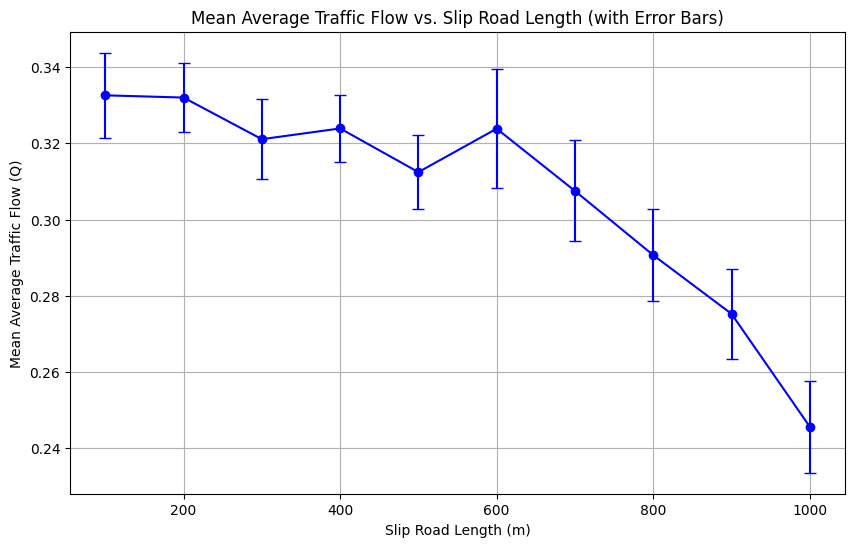

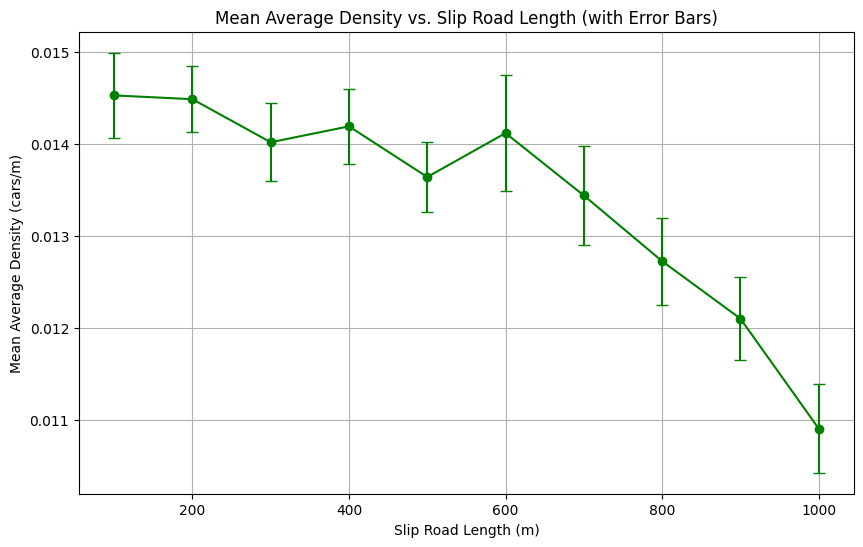

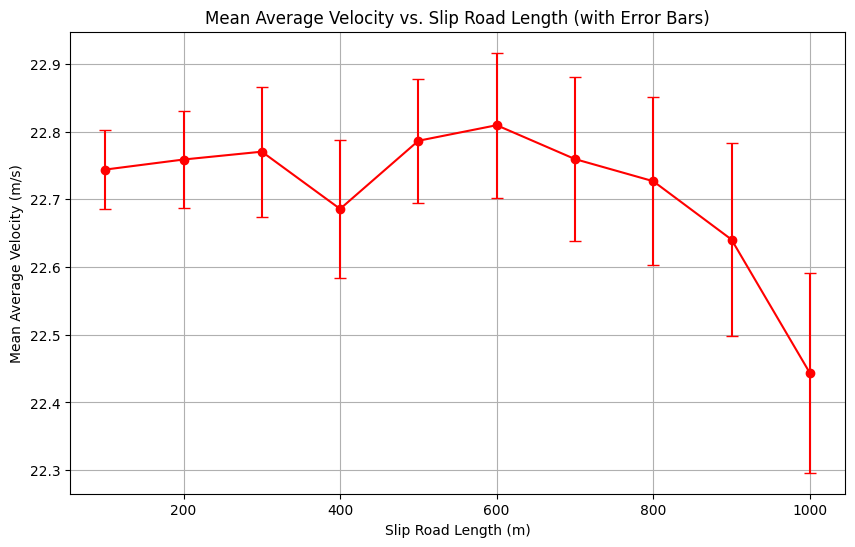

In [59]:
import matplotlib.pyplot as plt

# Plot Mean Average Traffic Flow
plt.figure(figsize=(10, 6))
plt.errorbar(slip_road_lengths, mean_avg_flows, yerr=std_avg_flows, marker='o', linestyle='-', color='blue', capsize=4)
plt.xlabel('Slip Road Length (m)')
plt.ylabel('Mean Average Traffic Flow (Q)')
plt.title('Mean Average Traffic Flow vs. Slip Road Length (with Error Bars)')
plt.grid(True)
plt.show()

# Plot Mean Average Density
plt.figure(figsize=(10, 6))
plt.errorbar(slip_road_lengths, mean_avg_densities, yerr=std_avg_densities, marker='o', linestyle='-', color='green', capsize=4)
plt.xlabel('Slip Road Length (m)')
plt.ylabel('Mean Average Density (cars/m)')
plt.title('Mean Average Density vs. Slip Road Length (with Error Bars)')
plt.grid(True)
plt.show()

# Plot Mean Average Velocity
plt.figure(figsize=(10, 6))
plt.errorbar(slip_road_lengths, mean_avg_velocities, yerr=std_avg_velocities, marker='o', linestyle='-', color='red', capsize=4)
plt.xlabel('Slip Road Length (m)')
plt.ylabel('Mean Average Velocity (m/s)')
plt.title('Mean Average Velocity vs. Slip Road Length (with Error Bars)')
plt.grid(True)
plt.show()


In [63]:
import numpy as np

splim_mph = np.arange(30, 201, 10)

print(f"Speed Limits (mph): {splim_mph}")

Speed Limits (mph): [ 30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180 190 200]


In [64]:
num_runs = 10 # Define the number of simulation runs for each speed limit

mean_avg_flows_splim = []
mean_avg_densities_splim = []
mean_avg_velocities_splim = []

std_avg_flows_splim = []
std_avg_densities_splim = []
std_avg_velocities_splim = []

# Fixed theta1 for this set of simulations (e.g., corresponding to L_slip = 500m)
# Based on previous calculations, theta1_values[4] corresponds to L_slip = 500m
fixed_theta1 = theta1_values[4]

# Note: L, theta0, and splim_mph are already defined in the global scope

for i, current_splim_mph in enumerate(splim_mph):
    print(f"\nProcessing speed limit: {current_splim_mph} mph")

    flows_for_current_splim = []
    densities_for_current_splim = []
    velocities_for_current_splim = []

    for run in range(num_runs):
        # print(f"  -> Running simulation run {run + 1}/{num_runs} for {current_splim_mph} mph")
        average_flow, average_density, average_velocity = run_simulation_and_collect_data(
            L=L,
            splim_mph=current_splim_mph, # Varying speed limit
            N0=20,
            p_in=0.2,
            p_out=0.2,
            theta0=theta0,
            theta1=fixed_theta1, # Fixed slip road length
            gap_factor=1,
            steps=2000
        )
        flows_for_current_splim.append(average_flow)
        densities_for_current_splim.append(average_density)
        velocities_for_current_splim.append(average_velocity)

    # Calculate the mean and standard deviation of the collected metrics for the current speed limit
    mean_flow = np.mean(flows_for_current_splim)
    mean_density = np.mean(densities_for_current_splim)
    mean_velocity = np.mean(velocities_for_current_splim)

    std_flow = np.std(flows_for_current_splim)
    std_density = np.std(densities_for_current_splim)
    std_velocity = np.std(velocities_for_current_splim)

    mean_avg_flows_splim.append(mean_flow)
    mean_avg_densities_splim.append(mean_density)
    mean_avg_velocities_splim.append(mean_velocity)

    std_avg_flows_splim.append(std_flow)
    std_avg_densities_splim.append(std_density)
    std_avg_velocities_splim.append(std_velocity)

    print(f"  Avg. across {num_runs} runs: Flow={mean_flow:.4f} (std={std_flow:.4f}), Density={mean_density:.4f} (std={std_density:.4f}), Velocity={mean_velocity:.4f} (std={std_velocity:.4f})")

print("\n--- Averaged Simulation Results Across Multiple Runs (Speed Limit Variation) ---")
print(f"Speed Limits (mph): {splim_mph.tolist()}")
print(f"Mean Average Flows: {mean_avg_flows_splim}")
print(f"Std Dev Average Flows: {std_avg_flows_splim}")
print(f"Mean Average Densities: {mean_avg_densities_splim}")
print(f"Std Dev Average Densities: {std_avg_densities_splim}")
print(f"Mean Average Velocities: {mean_avg_velocities_splim}")
print(f"Std Dev Average Velocities: {std_avg_velocities_splim}")


Processing speed limit: 30 mph
  Avg. across 10 runs: Flow=0.2152 (std=0.0072), Density=0.0178 (std=0.0006), Velocity=11.9755 (std=0.0433)

Processing speed limit: 40 mph
  Avg. across 10 runs: Flow=0.2506 (std=0.0083), Density=0.0163 (std=0.0005), Velocity=15.2977 (std=0.0748)

Processing speed limit: 50 mph
  Avg. across 10 runs: Flow=0.2821 (std=0.0113), Density=0.0153 (std=0.0006), Velocity=18.2873 (std=0.1072)

Processing speed limit: 60 mph
  Avg. across 10 runs: Flow=0.2957 (std=0.0055), Density=0.0142 (std=0.0003), Velocity=20.7442 (std=0.0929)

Processing speed limit: 70 mph
  Avg. across 10 runs: Flow=0.3143 (std=0.0159), Density=0.0138 (std=0.0007), Velocity=22.6857 (std=0.1046)

Processing speed limit: 80 mph
  Avg. across 10 runs: Flow=0.3268 (std=0.0111), Density=0.0134 (std=0.0004), Velocity=24.3144 (std=0.1448)

Processing speed limit: 90 mph
  Avg. across 10 runs: Flow=0.3446 (std=0.0129), Density=0.0134 (std=0.0004), Velocity=25.5965 (std=0.1835)

Processing speed li

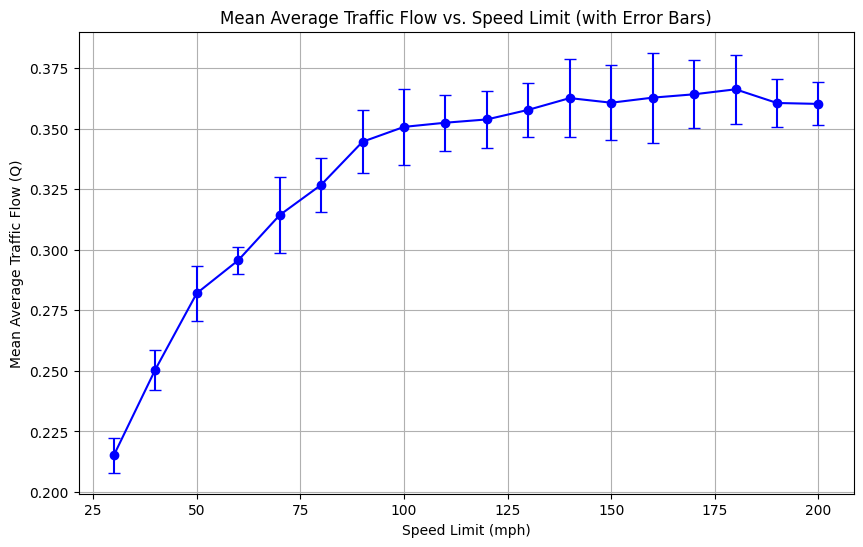

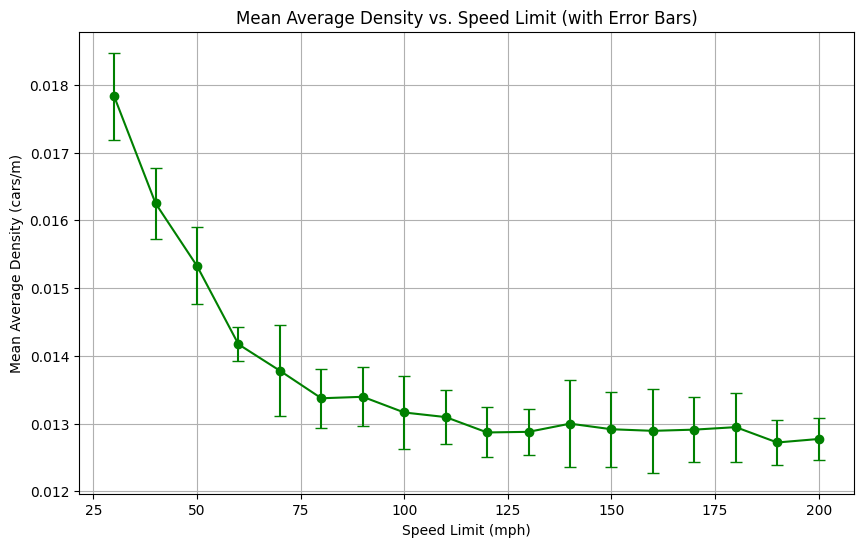

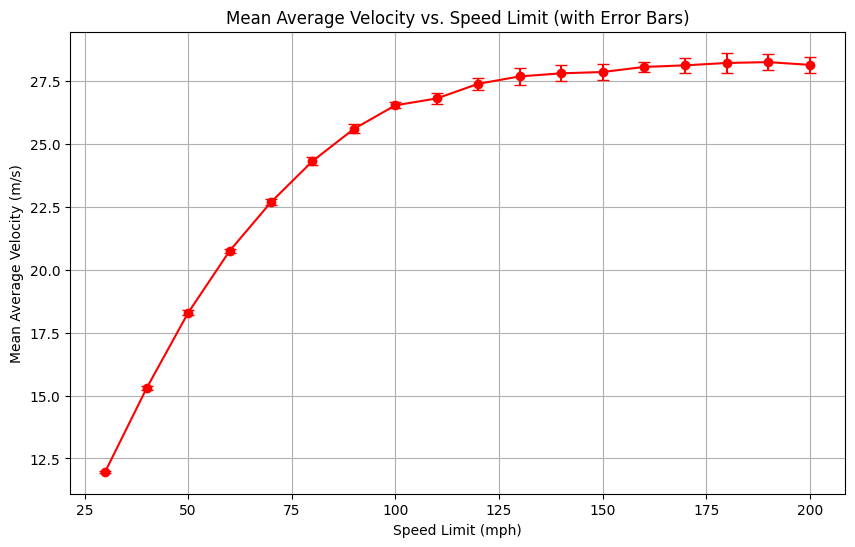

In [65]:
import matplotlib.pyplot as plt

# Plot Mean Average Traffic Flow vs. Speed Limit
plt.figure(figsize=(10, 6))
plt.errorbar(splim_mph, mean_avg_flows_splim, yerr=std_avg_flows_splim, marker='o', linestyle='-', color='blue', capsize=4)
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Mean Average Traffic Flow (Q)')
plt.title('Mean Average Traffic Flow vs. Speed Limit (with Error Bars)')
plt.grid(True)
plt.show()

# Plot Mean Average Density vs. Speed Limit
plt.figure(figsize=(10, 6))
plt.errorbar(splim_mph, mean_avg_densities_splim, yerr=std_avg_densities_splim, marker='o', linestyle='-', color='green', capsize=4)
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Mean Average Density (cars/m)')
plt.title('Mean Average Density vs. Speed Limit (with Error Bars)')
plt.grid(True)
plt.show()

# Plot Mean Average Velocity vs. Speed Limit
plt.figure(figsize=(10, 6))
plt.errorbar(splim_mph, mean_avg_velocities_splim, yerr=std_avg_velocities_splim, marker='o', linestyle='-', color='red', capsize=4)
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Mean Average Velocity (m/s)')
plt.title('Mean Average Velocity vs. Speed Limit (with Error Bars)')
plt.grid(True)
plt.show()

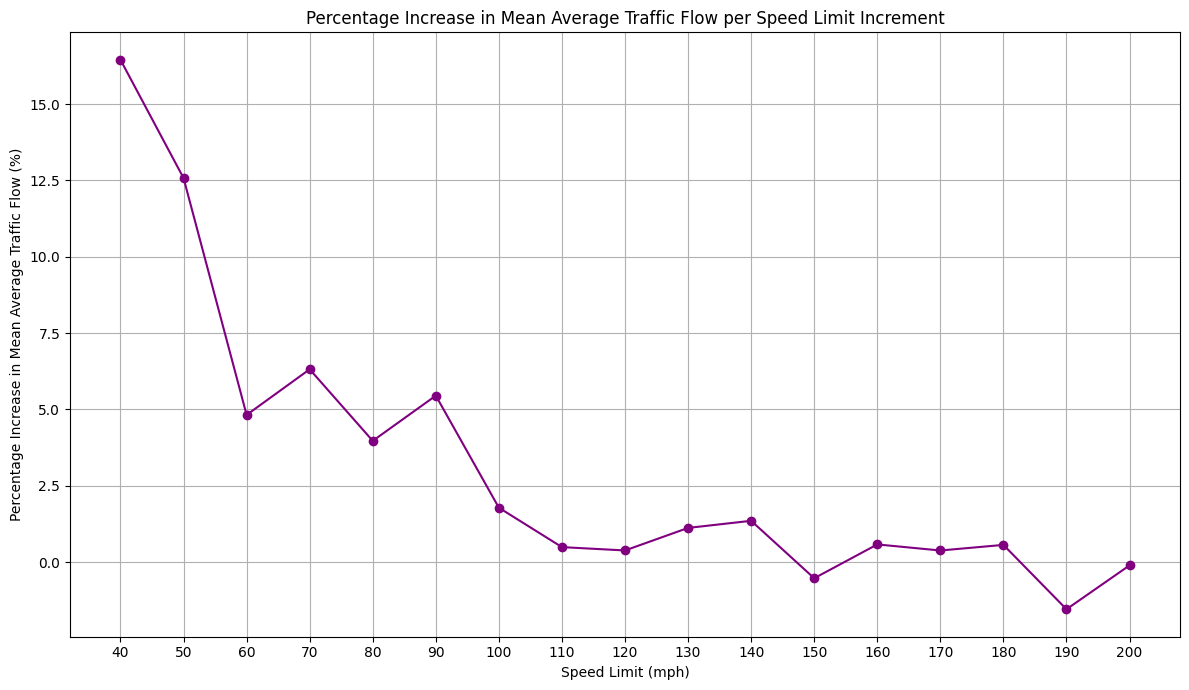

Percentage increase in flow for each speed limit increment:
  From 30 mph to 40 mph: 16.45%
  From 40 mph to 50 mph: 12.58%
  From 50 mph to 60 mph: 4.82%
  From 60 mph to 70 mph: 6.31%
  From 70 mph to 80 mph: 3.97%
  From 80 mph to 90 mph: 5.45%
  From 90 mph to 100 mph: 1.78%
  From 100 mph to 110 mph: 0.49%
  From 110 mph to 120 mph: 0.38%
  From 120 mph to 130 mph: 1.12%
  From 130 mph to 140 mph: 1.35%
  From 140 mph to 150 mph: -0.53%
  From 150 mph to 160 mph: 0.58%
  From 160 mph to 170 mph: 0.38%
  From 170 mph to 180 mph: 0.57%
  From 180 mph to 190 mph: -1.54%
  From 190 mph to 200 mph: -0.11%


In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the percentage increase in mean average traffic flow for each speed limit increment
percentage_increase_flow = []
for i in range(1, len(mean_avg_flows_splim)):
    # (Current_Flow - Previous_Flow) / Previous_Flow * 100
    if mean_avg_flows_splim[i-1] != 0:
        increase = ((mean_avg_flows_splim[i] - mean_avg_flows_splim[i-1]) / mean_avg_flows_splim[i-1]) * 100
        percentage_increase_flow.append(increase)
    else:
        percentage_increase_flow.append(0.0) # Handle division by zero if initial flow is zero

# The x-axis for this plot will be the upper speed limit of each interval
# So, it will start from the second speed limit in the splim_mph array
speed_limit_intervals = splim_mph[1:]

# Plot Percentage Increase in Mean Average Traffic Flow vs. Speed Limit
plt.figure(figsize=(12, 7))
plt.plot(speed_limit_intervals, percentage_increase_flow, marker='o', linestyle='-', color='purple')
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Percentage Increase in Mean Average Traffic Flow (%)')
plt.title('Percentage Increase in Mean Average Traffic Flow per Speed Limit Increment')
plt.grid(True)
plt.xticks(speed_limit_intervals) # Ensure all speed limit values are shown on x-axis
plt.tight_layout()
plt.show()

print("Percentage increase in flow for each speed limit increment:")
for i, val in enumerate(percentage_increase_flow):
    print(f"  From {splim_mph[i]} mph to {splim_mph[i+1]} mph: {val:.2f}%")